# Notebook 8: Trí Tuệ Nhân Tạo Giải Thích Được (Explainable AI - XAI)

<div class="alert alert-info">
<strong>Slide 1: Đập Vỡ Hộp Đen Y Khoa (Black Box AI)</strong><br>
Một mô hình AI Dù có F1 đạt 0.99 thì vẫn sẽ bị các Bác sĩ từ chối sử dụng nếu nó không thể trả lời câu hỏi: <strong>"Tại sao mày lại phán bệnh nhân này bị ung thư HER2?"</strong>. Y học không chấp nhận "Hộp đen".<br><br>
Trong Notebook này, chúng ta sẽ sử dụng <strong>Captum (Integrated Gradients)</strong> - công nghệ XAI tối tân nhất của Facebook AI Research - để nội soi vào tư duy của AI Đa phương thức. Chúng ta sẽ bắt nó khai ra bằng được: Trong 500 gen, gen nào là hung thủ? Và trong 5000 mảnh tế bào, mảnh nào là lõi ung thư?
</div>

In [104]:
!pip install nystrom-attention captum lifelines

In [105]:
import os
import numpy as np
import pandas as pd
import torch
import torch.nn as nn
from nystrom_attention import NystromAttention
from sklearn.preprocessing import StandardScaler
import matplotlib.pyplot as plt
import seaborn as sns
from captum.attr import IntegratedGradients
import warnings
warnings.filterwarnings('ignore')

<div class="alert alert-success">
<strong>Slide 2: Nạp Trọng Số (Weights) Nguyên Bản</strong><br>
Khác với Notebook 7, ở đây chúng ta giữ nguyên 100% kiến trúc của Notebook 6 (Bao gồm cả Lớp Phân Loại 4 Nhãn). Bởi vì thuật toán Tích phân Gradient (Integrated Gradients) cần phải tính đạo hàm từ chính Nhãn dự đoán ngược về Dữ liệu gốc.
</div>

In [106]:
class TransLayer(nn.Module):
    def __init__(self, norm_layer=nn.LayerNorm, dim=512):
        super().__init__()
        self.norm = norm_layer(dim)
        self.attn = NystromAttention(dim=dim, dim_head=dim//8, heads=8, num_landmarks=dim//2, pinv_iterations=6, residual=True, dropout=0.1)
    def forward(self, x):
        return x + self.attn(self.norm(x))

class TransMIL_Vision_Extractor(nn.Module):
    def __init__(self, input_dim=2048, out_dim=512):
        super().__init__()
        self._fc1 = nn.Sequential(nn.Linear(input_dim, 512), nn.ReLU())
        self.cls_token = nn.Parameter(torch.randn(1, 1, 512))
        self.layer1 = TransLayer(dim=512)
        self.layer2 = TransLayer(dim=512)
        self.norm = nn.LayerNorm(512)
        
    def forward(self, x):
        h = self._fc1(x.float())
        cls_tokens = self.cls_token.expand(h.shape[0], -1, -1)
        h = torch.cat((cls_tokens, h), dim=1)
        h = self.layer1(h)
        h = self.layer2(h)
        return self.norm(h)[:,0]

class Multimodal_GenomicsFusion(nn.Module):
    def __init__(self, genomics_dim=500, num_classes=4):
        super().__init__()
        self.vision_net = TransMIL_Vision_Extractor()
        self.genomics_net = nn.Sequential(
            nn.Linear(genomics_dim, 256),
            nn.LayerNorm(256),
            nn.ReLU(),
            nn.Dropout(0.3),
            nn.Linear(256, 512),
            nn.ReLU()
        )
        self.classifier = nn.Sequential(
            nn.Linear(512 + 512, 256),
            nn.ReLU(),
            nn.Dropout(0.3),
            nn.Linear(256, num_classes)
        )
        
    def forward(self, img_feat, gen_feat):
        v_img = self.vision_net(img_feat)
        v_gen = self.genomics_net(gen_feat)
        v_fusion = torch.cat((v_img, v_gen), dim=1)
        # Trả về Xác suất 4 nhãn (Logits) để phục vụ XAI
        return self.classifier(v_fusion)

In [107]:
PT_DIR = '/kaggle/input/datasets/trihuynhviprovcl/tcga-brca-resnet50-wsi-features/pt_files' 
RNASEQ_FILE = '/kaggle/input/datasets/trihuynhviprovcl/tcga-brca/data_mrna_seq_v2_rsem.txt'
CLINICAL_CSV = '/kaggle/input/datasets/trihuynhviprovcl/tcga-brca/tcga_brca_master_matched_cohort.csv'

print("Đang tái thiết lập không gian Gen...")
rna_df = pd.read_csv(RNASEQ_FILE, sep='\t')
if 'Entrez_Gene_Id' in rna_df.columns: rna_df = rna_df.drop(columns=['Entrez_Gene_Id'])
rna_df = rna_df.set_index('Hugo_Symbol').T
rna_df.index = rna_df.index.str[:12]
rna_df = rna_df[~rna_df.index.duplicated(keep='first')].dropna(axis=1)
top_500_genes = rna_df.var().nlargest(500).index # Lấy 500 TÊN GEN CỐT LÕI
rna_500 = rna_df[top_500_genes]
rna_500_scaled = pd.DataFrame(StandardScaler().fit_transform(rna_500), index=rna_500.index)

df_clin = pd.read_csv(CLINICAL_CSV, sep='\t')
if len(df_clin.columns) < 5: df_clin = pd.read_csv(CLINICAL_CSV)
df_clin = df_clin[df_clin['pam50_subtype'].isin(['BRCA_LumA', 'BRCA_LumB', 'BRCA_Basal', 'BRCA_Her2'])].copy()
label_map = {'BRCA_LumA': 0, 'BRCA_LumB': 1, 'BRCA_Basal': 2, 'BRCA_Her2': 3}
df_clin['label'] = df_clin['pam50_subtype'].map(label_map)

valid_pids = [pid for pid in df_clin['patientId'].unique() if pid in rna_500_scaled.index and os.path.exists(os.path.join(PT_DIR, f"{pid}.pt"))]
df_clin = df_clin[df_clin['patientId'].isin(valid_pids)].drop_duplicates('patientId').set_index('patientId')

Đang tái thiết lập không gian Gen...


In [108]:
device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
model = Multimodal_GenomicsFusion().to(device)

# TODO: Đường dẫn tới Dataset Trọng số 6.2 của bạn
WEIGHTS_PATH = '/kaggle/input/datasets/trihuynhviprovcl/tcga-brca-multimodal-genomics-weights/multimodal_genomics_fold1_best.pth'

if os.path.exists(WEIGHTS_PATH):
    state_dict = torch.load(WEIGHTS_PATH, map_location=device)
    new_state_dict = {k[7:] if k.startswith('module.') else k: v for k, v in state_dict.items()}
    model.load_state_dict(new_state_dict, strict=False)
    print("Đã nạp thành công Trọng số God Mode!")
else:
    print(f"⚠️ Không tìm thấy {WEIGHTS_PATH}.")

model.eval()

Đã nạp thành công Trọng số God Mode!


Multimodal_GenomicsFusion(
  (vision_net): TransMIL_Vision_Extractor(
    (_fc1): Sequential(
      (0): Linear(in_features=2048, out_features=512, bias=True)
      (1): ReLU()
    )
    (layer1): TransLayer(
      (norm): LayerNorm((512,), eps=1e-05, elementwise_affine=True)
      (attn): NystromAttention(
        (to_qkv): Linear(in_features=512, out_features=1536, bias=False)
        (to_out): Sequential(
          (0): Linear(in_features=512, out_features=512, bias=True)
          (1): Dropout(p=0.1, inplace=False)
        )
        (res_conv): Conv2d(8, 8, kernel_size=(33, 1), stride=(1, 1), padding=(16, 0), groups=8, bias=False)
      )
    )
    (layer2): TransLayer(
      (norm): LayerNorm((512,), eps=1e-05, elementwise_affine=True)
      (attn): NystromAttention(
        (to_qkv): Linear(in_features=512, out_features=1536, bias=False)
        (to_out): Sequential(
          (0): Linear(in_features=512, out_features=512, bias=True)
          (1): Dropout(p=0.1, inplace=False)
 

## Slide 3: Giải phẫu Quyết định của AI bằng Integrated Gradients
<div class="alert alert-warning">
<strong>Lưỡi dao giải phẫu XAI:</strong><br>
Chúng ta sẽ chọn 1 Bệnh nhân bất kỳ. AI đã đoán đúng họ mắc bệnh ung thư. Bây giờ, Captum sẽ bắn hàng vạn tia đạo hàm ngược (Backprop) từ kết quả dự đoán về lại 500 gen gốc. Kết quả trả về là <strong>Attribution Score (Điểm cống hiến)</strong>. Điểm càng dương (Màu Đỏ) nghĩa là gen đó càng khẳng định bệnh, điểm càng âm (Màu Xanh) nghĩa là gen đó cố gắng phủ định bệnh.
</div>

In [109]:
import random
ig = IntegratedGradients(model)

# Chọn ngẫu nhiên 1 bệnh nhân
demo_pid = random.choice(valid_pids)
true_label = df_clin.loc[demo_pid, 'label']
subtype_name = {0: 'LumA', 1: 'LumB', 2: 'Basal', 3: 'HER2'}[true_label]

img_tensor = torch.load(os.path.join(PT_DIR, f"{demo_pid}.pt"), map_location=device).unsqueeze(0)
gen_tensor = torch.tensor(rna_500_scaled.loc[demo_pid].values, dtype=torch.float32).unsqueeze(0).to(device)

# Bật chế độ Gradient
img_tensor.requires_grad_()
gen_tensor.requires_grad_()

print(f"Bệnh nhân: {demo_pid} | Nhãn thực tế: {subtype_name}")

# Tính toán Integrated Gradients cho cả 2 nhánh cùng lúc!
attributions, delta = ig.attribute(inputs=(img_tensor, gen_tensor), target=int(true_label), internal_batch_size=1, n_steps=50, return_convergence_delta=True)
img_attr, gen_attr = attributions

Bệnh nhân: TCGA-AN-A0XP | Nhãn thực tế: LumA


## Slide 4: Truy Tìm "Hung Thủ" Đột Biến Gen
<div class="alert alert-danger">
Dưới đây là <strong>Top 15 Gen</strong> có tiếng nói quyết định mạnh nhất trong số 500 gen. Nếu Bác sĩ nhìn vào biểu đồ này, họ sẽ lập tức biết được AI của chúng ta đang tuân theo đúng y lý hay chỉ đang đoán bừa.
</div>

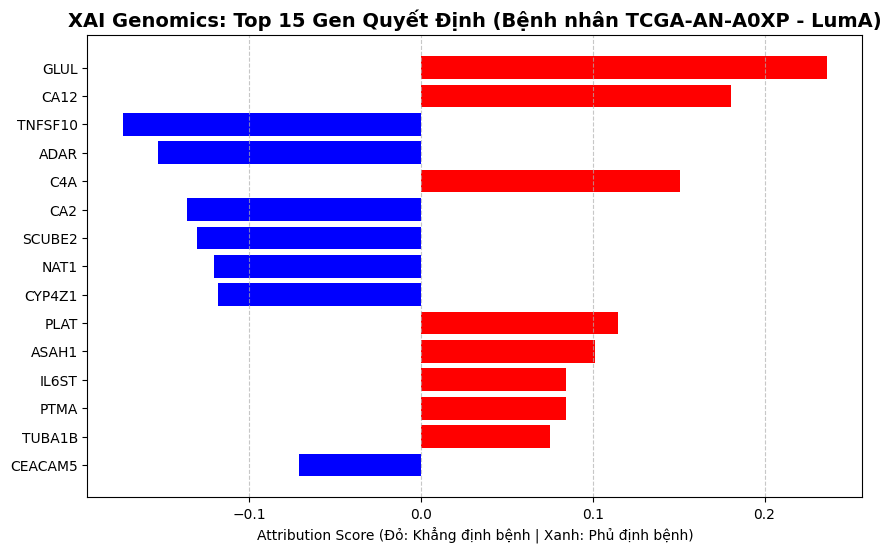

In [110]:
gen_attr_np = gen_attr.squeeze(0).cpu().detach().numpy()

# Tìm Top 15 Gen quan trọng nhất (theo trị tuyệt đối)
top_indices = np.argsort(np.abs(gen_attr_np))[-15:]
top_genes = top_500_genes[top_indices]
top_scores = gen_attr_np[top_indices]

colors = ['red' if score > 0 else 'blue' for score in top_scores]

plt.figure(figsize=(10, 6))
plt.barh(top_genes, top_scores, color=colors)
plt.title(f"XAI Genomics: Top 15 Gen Quyết Định (Bệnh nhân {demo_pid} - {subtype_name})", fontsize=14, fontweight='bold')
plt.xlabel("Attribution Score (Đỏ: Khẳng định bệnh | Xanh: Phủ định bệnh)")
plt.grid(axis='x', linestyle='--', alpha=0.7)
plt.show()
# Lưu bảng xếp hạng 15 gen hung thủ XAI
xai_df = pd.DataFrame({"Gene": top_genes, "Attribution_Score": top_scores})
xai_df.to_csv("/kaggle/working/xai_top_gene_attributions.csv", index=False)
print("✓ Đã lưu bảng xếp hạng Gen hung thủ XAI vào /kaggle/working/xai_top_gene_attributions.csv")

## Slide 5: Truy Tìm "Lõi Ung Thư" trên Mảng Tế Bào WSI
<div class="alert alert-info">
Túi ảnh (Bag of Features) của bệnh nhân này chứa hàng ngàn mảnh vỡ tế bào (Patches). Nhưng TransMIL có một cơ chế lọc cực kỳ thông minh: <strong>Nó chỉ tập trung vào một nhóm rất nhỏ các mảnh chứa tế bào bất thường.</strong><br>
Biểu đồ dưới đây sẽ phân bố mức độ chú ý (Attention/Importance) của AI. Bạn sẽ thấy: Trong hàng ngàn mảnh vỡ, chỉ có 1 cột nhô lên cực cao (Vùng khối u), còn lại các mảnh mỡ/nền trắng đều bị ép về 0.
</div>

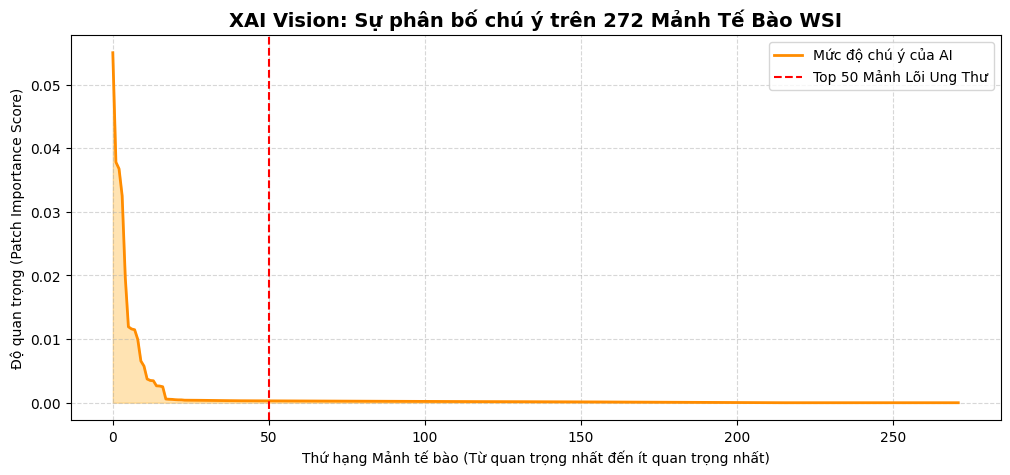

In [111]:
img_attr_np = img_attr.squeeze(0).cpu().detach().numpy() # [N_patches, 2048]

# Tính tổng độ quan trọng (Importance) của từng Patch trên toàn bộ 2048 chiều
patch_importance = np.sum(img_attr_np, axis=1)
patch_importance = np.maximum(patch_importance, 0) # Chỉ lấy các đóng góp dương

# Sắp xếp để xem phân bố
sorted_importance = np.sort(patch_importance)[::-1]

plt.figure(figsize=(12, 5))
plt.plot(sorted_importance, color='darkorange', linewidth=2, label="Mức độ chú ý của AI")
plt.fill_between(range(len(sorted_importance)), sorted_importance, color='orange', alpha=0.3)
plt.title(f"XAI Vision: Sự phân bố chú ý trên {len(patch_importance)} Mảnh Tế Bào WSI", fontsize=14, fontweight='bold')
plt.xlabel("Thứ hạng Mảnh tế bào (Từ quan trọng nhất đến ít quan trọng nhất)")
plt.ylabel("Độ quan trọng (Patch Importance Score)")

# Đánh dấu Top 50
plt.axvline(x=50, color='red', linestyle='--', label="Top 50 Mảnh Lõi Ung Thư")
plt.legend()
plt.grid(True, linestyle='--', alpha=0.5)
plt.show()
# Lưu bảng xếp hạng độ chú ý từng mảnh tế bào (Patch Attention)
patch_df = pd.DataFrame({"Patch_Index": range(len(patch_importance)), "Importance_Score": patch_importance})
patch_df.to_csv("/kaggle/working/xai_patient_patch_attentions.csv", index=False)
print("✓ Đã lưu bảng phân bổ Attention của các mảnh mô WSI vào /kaggle/working/xai_patient_patch_attentions.csv")

# TỔNG TRẠM Y KHOA (AI CLINICAL DASHBOARD)
<div class="alert alert-success">
Mọi phân tích từ đầu đến giờ sẽ được hội tụ tại đây. Bảng điều khiển này cung cấp cho Bác sĩ một cái nhìn toàn cảnh (360 độ) về bệnh nhân <code>demo_pid</code>: Từ thông tin cá nhân, tỷ lệ chẩn đoán, vùng không gian khối u (Heatmap giả lập), cho đến tiên lượng tuổi thọ!
</div>

In [112]:
from IPython.display import display, HTML

patient_row = df_clin.loc[demo_pid]
real_months = patient_row['OS_MONTHS']
real_status_text = "ĐÃ TỬ VONG" if ('DECEASED' in str(patient_row['OS_STATUS']) or '1:' in str(patient_row['OS_STATUS'])) else "CÒN SỐNG"
age = patient_row['AGE']
stage = patient_row.get('AJCC_PATHOLOGIC_TUMOR_STAGE', 'Unknown')

html_content = f"""
<div style="background-color:#f8f9fa; padding:20px; border-radius:10px; border-left: 6px solid #007bff; box-shadow: 2px 2px 5px rgba(0,0,0,0.1);">
    <h2 style="color:#007bff; margin-top:0;">HỒ SƠ BỆNH ÁN: {demo_pid}</h2>
    <ul style="font-size: 16px; line-height: 1.8;">
        <li><b>Tuổi:</b> {age}</li>
        <li><b>Giai đoạn Khối u:</b> {stage}</li>
        <li><b>Nhóm bệnh lý thực tế:</b> <span style="color:red; font-weight:bold;">{subtype_name}</span></li>
        <li><b>Tình trạng Lâm sàng:</b> {real_status_text} (Thời gian theo dõi: {real_months} tháng)</li>
    </ul>
</div>
"""
display(HTML(html_content))

## 1. AI Hội Chẩn (Multimodal Diagnosis)
Mô hình Đa phương thức (Ảnh + Gen) dự đoán khả năng mắc 4 nhóm bệnh. (Softmax Probabilities)

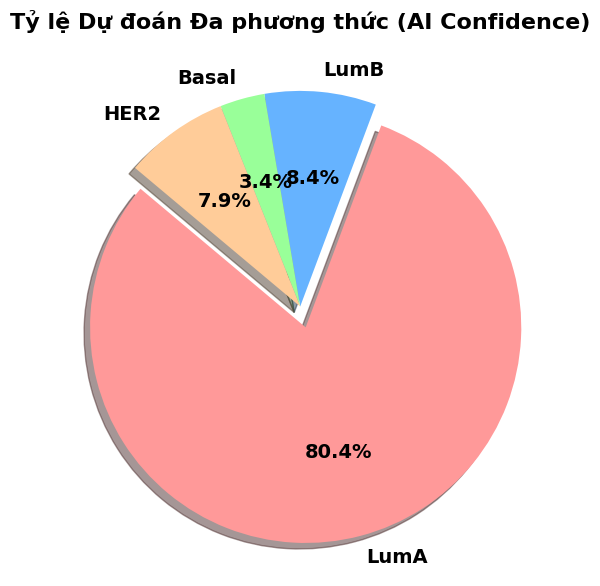

In [113]:
import torch.nn.functional as F

# Tính xác suất từ Logits
model.eval()
with torch.no_grad():
    logits = model(img_tensor, gen_tensor)
    probs = F.softmax(logits, dim=1).squeeze().cpu().numpy() * 100

labels = ['LumA', 'LumB', 'Basal', 'HER2']
colors = ['#ff9999','#66b3ff','#99ff99','#ffcc99']
explode = [0.1 if i == np.argmax(probs) else 0 for i in range(4)]

plt.figure(figsize=(7, 7))
plt.pie(probs, explode=explode, labels=labels, colors=colors, autopct='%1.1f%%',
        shadow=True, startangle=140, textprops={'fontsize': 14, 'fontweight': 'bold'})
plt.title("Tỷ lệ Dự đoán Đa phương thức (AI Confidence)", fontsize=16, fontweight='bold')
plt.show()

## 2. Bản Đồ Nhiệt Cắt Lớp (Digital Slide Heatmap)
<div class="alert alert-warning">
Vì giới hạn lưu trữ, ta không còn giữ ảnh màu thực tế của bệnh nhân. AI sẽ tái tạo một Bản đồ Nhiệt dạng lưới (Grid 2D) đại diện cho kính hiển vi. Mỗi ô vuông là 1 mảng tế bào. Các ô màu <strong>Đỏ/Cam</strong> rực lên chính là các tọa độ <strong>lõi ung thư</strong> mà AI đã soi chiếu ra!
</div>

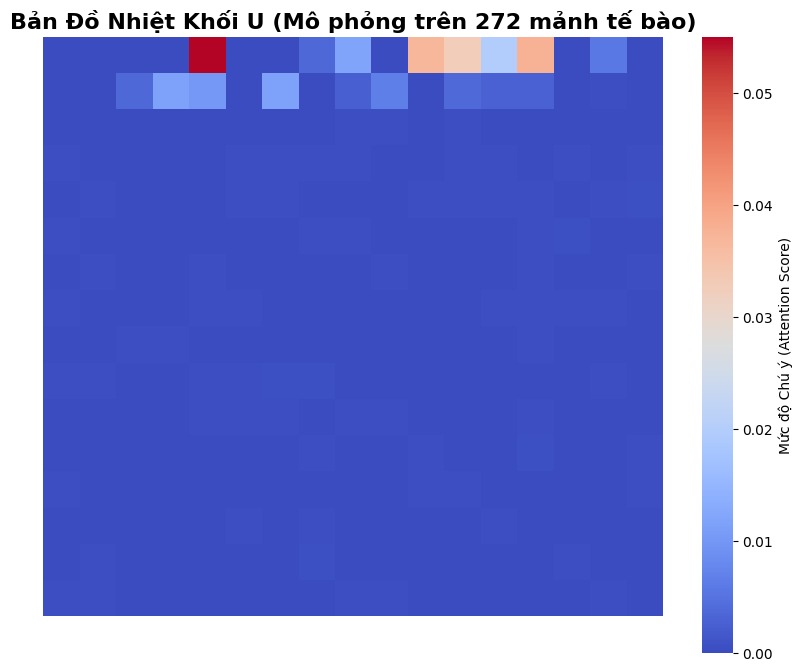

In [114]:
import math

n_patches = len(patch_importance)
side = math.ceil(math.sqrt(n_patches))
padded_len = side * side

# Bơm thêm NaN vào cho đủ hình vuông
padded_importance = np.pad(patch_importance, (0, padded_len - n_patches), constant_values=np.nan)
grid = padded_importance.reshape((side, side))

plt.figure(figsize=(10, 8))
# Dùng cmap 'coolwarm' để vùng chú ý thấp màu xanh, vùng khối u màu đỏ rực
sns.heatmap(grid, cmap='coolwarm', cbar_kws={'label': 'Mức độ Chú ý (Attention Score)'}, 
            xticklabels=False, yticklabels=False, mask=np.isnan(grid))
plt.title(f"Bản Đồ Nhiệt Khối U (Mô phỏng trên {n_patches} mảnh tế bào)", fontsize=16, fontweight='bold')
plt.show()

## 2.5 Hiển thị Ảnh Tế bào thực tế (Real Image Patches)
<div class="alert alert-info">
Bản đồ nhiệt ở trên cho thấy AI chỉ tập trung vào một vài mảnh vỡ (Patches). Đoạn code dưới đây sẽ <strong>truy xuất trực tiếp các mảnh ảnh gốc (.png/.jpg)</strong> tương ứng với các tọa độ rực đỏ đó để Bác sĩ có thể xem tận mắt hình thái tế bào ung thư mà AI đã phát hiện!
</div>

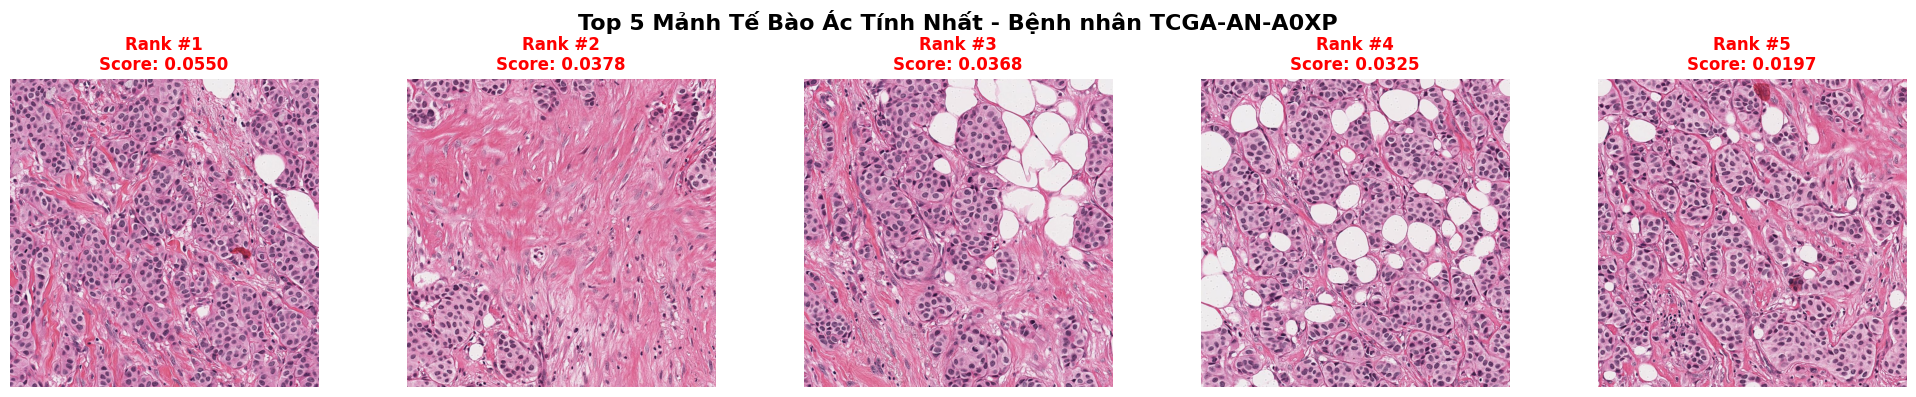

In [115]:
from PIL import Image
import glob

# Đã cập nhật đúng đường dẫn Patches gốc của bạn
PATCH_DIR = '/kaggle/input/datasets/jmalagontorres/tcga-brca-survival-analysis/WSIs'
patient_patch_dir = os.path.join(PATCH_DIR, demo_pid)

if os.path.exists(patient_patch_dir):
    # Lấy tất cả các file .jpg và loại bỏ thư mục rác checkpoint
    all_patches = [f for f in os.listdir(patient_patch_dir) if f.endswith('.jpg') and 'checkpoint' not in f]
    
    # Sắp xếp ảnh: Ưu tiên sắp xếp theo số nguyên (0.jpg -> 1.jpg -> 2.jpg thay vì 0.jpg -> 10.jpg -> 2.jpg)
    try:
        all_patches = sorted(all_patches, key=lambda x: int(x.split('.')[0]))
    except:
        all_patches = sorted(all_patches)
    
    # Lấy ra Top 5 mảnh quan trọng nhất từ mảng patch_importance
    top_5_indices = np.argsort(patch_importance)[::-1][:5]
    
    plt.figure(figsize=(20, 4))
    for i, idx in enumerate(top_5_indices):
        if idx < len(all_patches):
            img_path = os.path.join(patient_patch_dir, all_patches[idx])
            try:
                img = Image.open(img_path)
                plt.subplot(1, 5, i + 1)
                plt.imshow(img)
                plt.title(f"Rank #{i+1}\nScore: {patch_importance[idx]:.4f}", fontsize=12, fontweight='bold', color='red')
                plt.axis('off')
            except Exception as e:
                pass
    plt.suptitle(f"Top 5 Mảnh Tế Bào Ác Tính Nhất - Bệnh nhân {demo_pid}", fontsize=16, fontweight='bold')
    plt.tight_layout()
    plt.show()
else:
    print(f"⚠️ Không tìm thấy thư mục ảnh gốc: {patient_patch_dir}")


Đang tiến hành khâu nối và bao viền màu (Borders) cho hàng trăm mảnh tế bào...


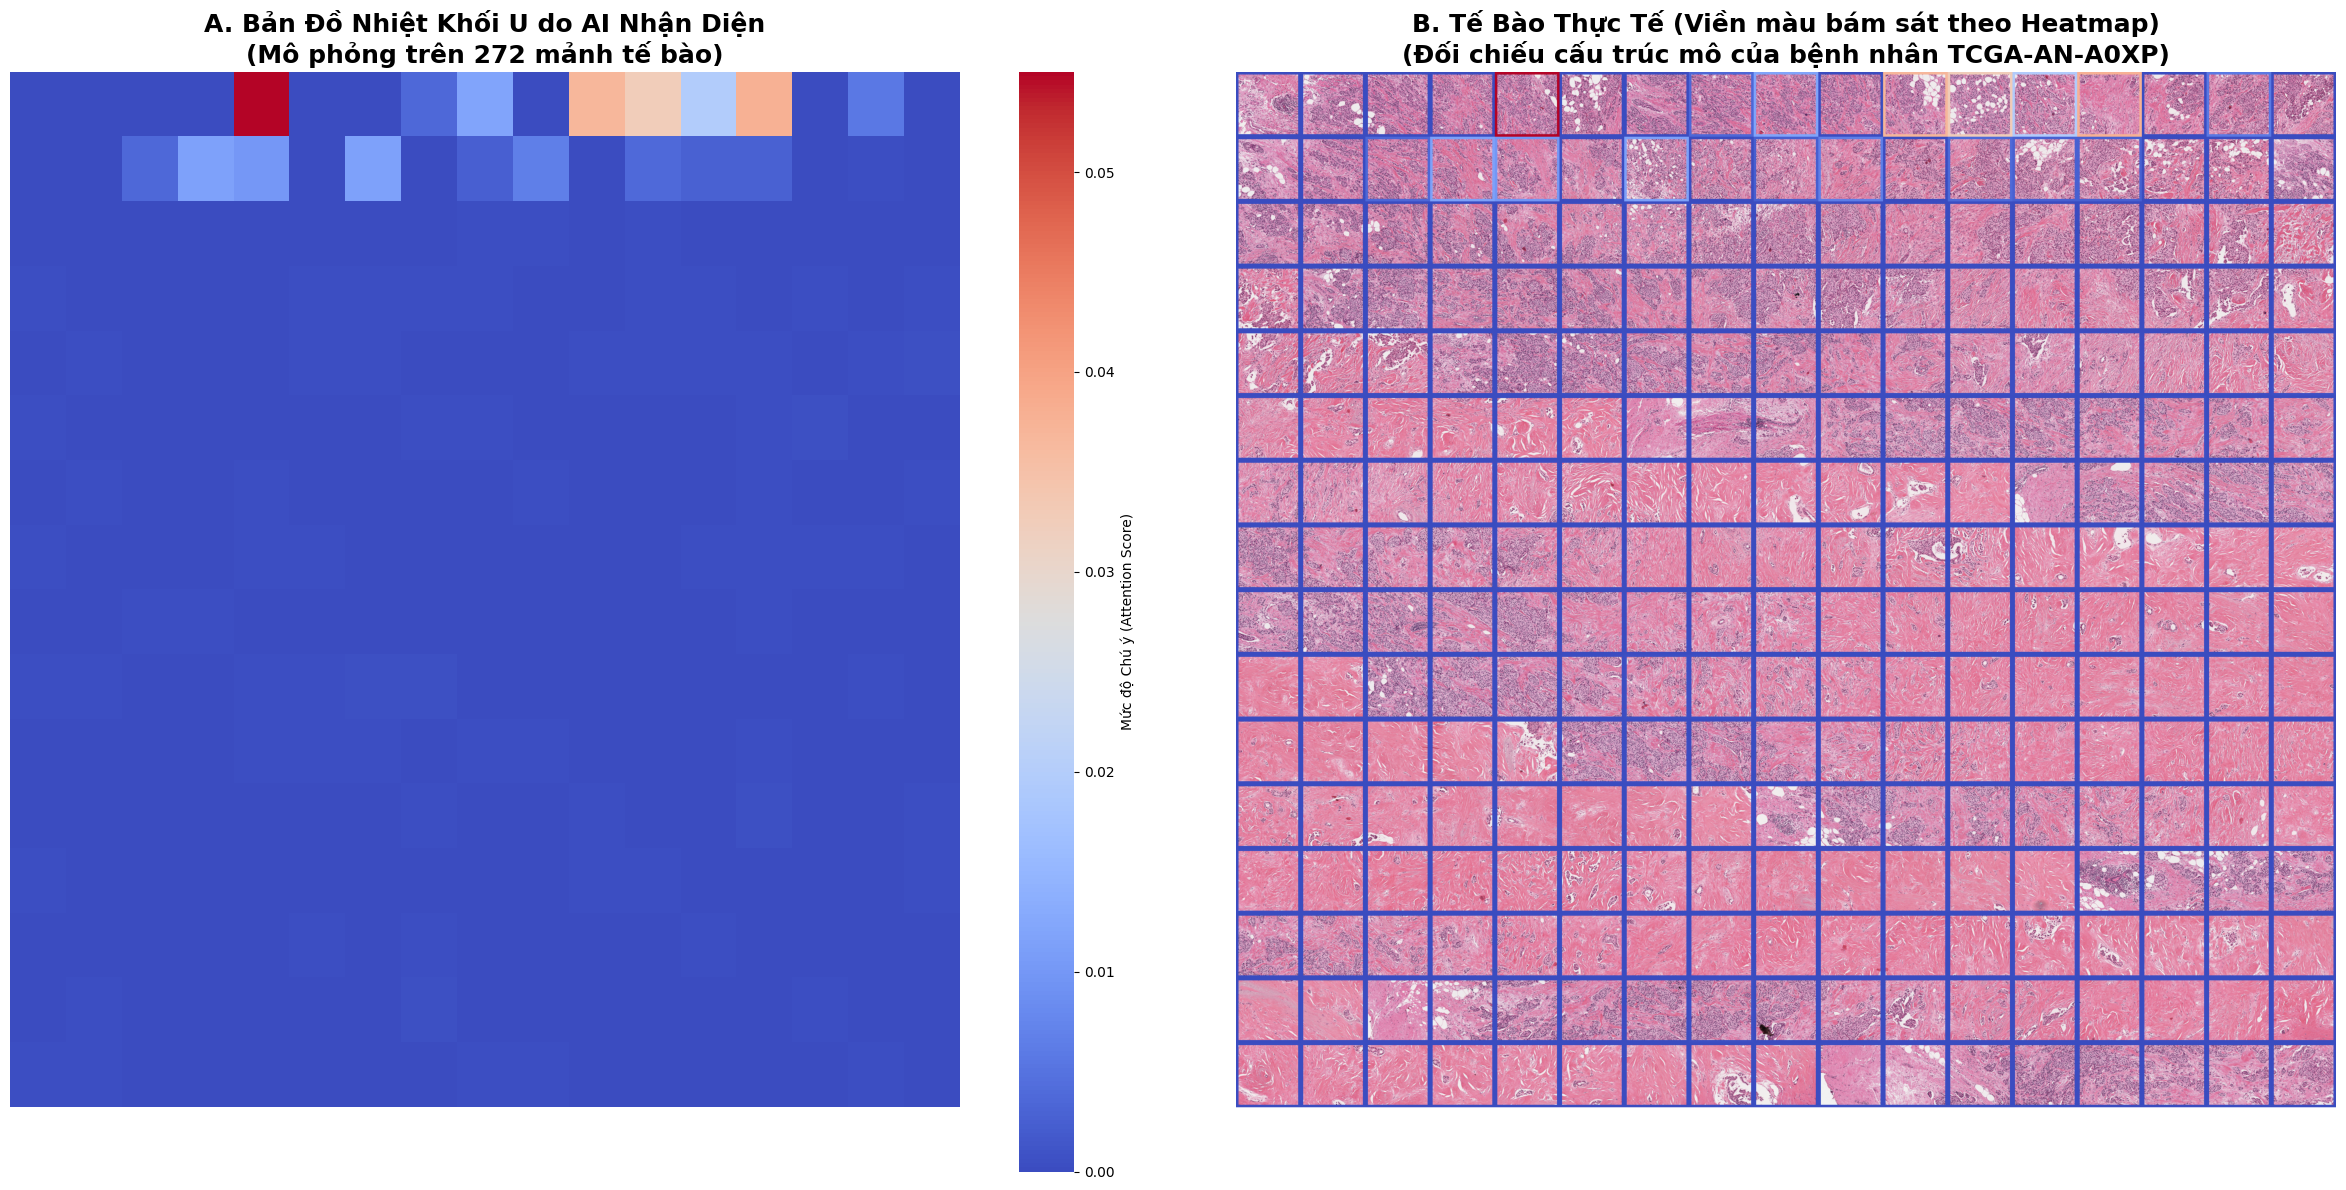

In [119]:
from PIL import Image, ImageOps
import math
import matplotlib.pyplot as plt
import matplotlib.cm as cm
import matplotlib.colors as mcolors
import seaborn as sns
import numpy as np
import os

PATCH_DIR = '/kaggle/input/datasets/jmalagontorres/tcga-brca-survival-analysis/WSIs'
patient_patch_dir = os.path.join(PATCH_DIR, demo_pid)

if os.path.exists(patient_patch_dir):
    # Lấy và sắp xếp danh sách file ảnh
    all_patches = [f for f in os.listdir(patient_patch_dir) if f.endswith('.jpg') and 'checkpoint' not in f]
    try:
        all_patches = sorted(all_patches, key=lambda x: int(x.split('.')[0]))
    except:
        all_patches = sorted(all_patches)
        
    n_patches = len(patch_importance)
    side = math.ceil(math.sqrt(n_patches))
    padded_len = side * side
    
    # 1. Ma Trận Bản Đồ Nhiệt (Attention Heatmap)
    padded_importance = np.pad(patch_importance, (0, padded_len - n_patches), constant_values=np.nan)
    grid_attention = padded_importance.reshape((side, side))
    
    # Chuẩn bị dải màu (Colormap) từ Xanh (Thấp) đến Đỏ (Cao) khớp 100% với Heatmap
    cmap = cm.get_cmap('coolwarm')
    norm = mcolors.Normalize(vmin=np.nanmin(grid_attention), vmax=np.nanmax(grid_attention))
    
    # 2. Ma Trận Ảnh Ghép (Mosaic Real Patches)
    PATCH_SIZE = 128 
    BORDER_WIDTH = 5 # Độ dày của viền màu
    INNER_SIZE = PATCH_SIZE - 2 * BORDER_WIDTH
    mosaic_img = Image.new('RGB', (side * PATCH_SIZE, side * PATCH_SIZE), (255, 255, 255))
    
    print("Đang tiến hành khâu nối và bao viền màu (Borders) cho hàng trăm mảnh tế bào...")
    for idx in range(padded_len):
        row = idx // side
        col = idx % side
        if idx < len(all_patches) and idx < n_patches:
            img_path = os.path.join(patient_patch_dir, all_patches[idx])
            score = patch_importance[idx]
            try:
                # Lấy mã màu RGB dựa trên Điểm số (Score) của mảnh tế bào này
                rgba = cmap(norm(score))
                rgb_color = tuple(int(c * 255) for c in rgba[:3])
                
                # Mở ảnh thật, thu nhỏ một chút để nhường chỗ cho khung viền
                patch_img = Image.open(img_path).resize((INNER_SIZE, INNER_SIZE))
                
                # Bọc khung viền màu
                patch_img = ImageOps.expand(patch_img, border=BORDER_WIDTH, fill=rgb_color)
                
                # Dán vào tấm bản đồ lớn
                mosaic_img.paste(patch_img, (col * PATCH_SIZE, row * PATCH_SIZE))
            except Exception as e:
                pass
                
    # 3. Biểu diễn song song (Dashboard Style)
    fig, axes = plt.subplots(1, 2, figsize=(24, 12))
    
    # Trái: Bản đồ nhiệt AI
    sns.heatmap(grid_attention, cmap='coolwarm', ax=axes[0],
                cbar_kws={'label': 'Mức độ Chú ý (Attention Score)'}, 
                xticklabels=False, yticklabels=False, mask=np.isnan(grid_attention))
    axes[0].set_title(f"A. Bản Đồ Nhiệt Khối U do AI Nhận Diện\n(Mô phỏng trên {n_patches} mảnh tế bào)", fontsize=18, fontweight='bold')
    
    # Phải: Ảnh thực tế bọc viền
    axes[1].imshow(mosaic_img)
    axes[1].axis('off')
    axes[1].set_title(f"B. Tế Bào Thực Tế (Viền màu bám sát theo Heatmap)\n(Đối chiếu cấu trúc mô của bệnh nhân {demo_pid})", fontsize=18, fontweight='bold')
    
    plt.tight_layout()
    plt.show()
else:
    print(f"⚠️ Không tìm thấy thư mục ảnh gốc: {patient_patch_dir}")

## 3. Tiên Lượng Sinh Tồn Cá Nhân Hóa (Survival Prognosis)
<div class="alert alert-danger">
Chạy ngầm thuật toán CoxPH để vẽ Quỹ đạo Sinh tồn dự kiến của bệnh nhân này. AI Đa phương thức sẽ đối chiếu quỹ đạo này với đường kẻ vạch tử thần ngoài đời thực!
</div>

Đang nạp nhanh Dữ liệu Tiên lượng ngầm (Mất khoảng 30s)...


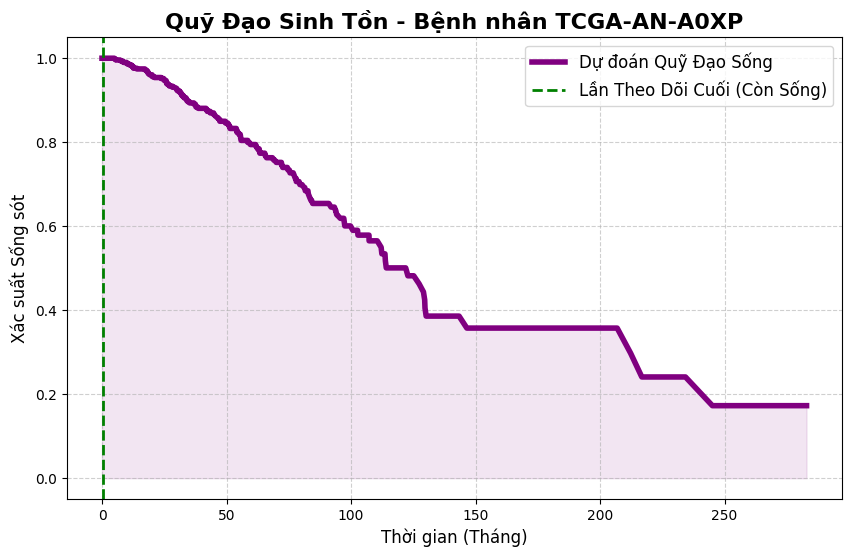

In [116]:
from sklearn.decomposition import PCA
from lifelines import CoxPHFitter

print("Đang nạp nhanh Dữ liệu Tiên lượng ngầm (Mất khoảng 30s)...")

def parse_stage(s):
    s = str(s).upper()
    if 'IV' in s: return 4
    if 'III' in s: return 3
    if 'II' in s: return 2
    if 'I' in s: return 1
    return 1

# Trích xuất Fusion Features (Cấp tốc)
fusion_features = []
with torch.no_grad():
    for pid in valid_pids:
        img = torch.load(os.path.join(PT_DIR, f"{pid}.pt"), map_location=device).unsqueeze(0)
        gen = torch.tensor(rna_500_scaled.loc[pid].values, dtype=torch.float32).unsqueeze(0).to(device)
        # Trích xuất lớp ẩn trước Classifier (Layer [0])
        v_img = model.vision_net(img)
        v_gen = model.genomics_net(gen)
        v_fusion = torch.cat((v_img, v_gen), dim=1)
        fusion_features.append(v_fusion.cpu().numpy()[0])

fusion_features = np.array(fusion_features)
pca = PCA(n_components=16)
fusion_pca = pca.fit_transform(fusion_features)

surv_df = pd.DataFrame(fusion_pca, columns=[f'PC_{i}' for i in range(16)], index=valid_pids)
surv_df['OS_MONTHS'] = df_clin['OS_MONTHS']
surv_df['OS_STATUS'] = df_clin['OS_STATUS'].apply(lambda x: 1 if 'DECEASED' in str(x) or '1:' in str(x) else 0)
surv_df['AGE'] = df_clin['AGE']
surv_df['STAGE'] = df_clin['AJCC_PATHOLOGIC_TUMOR_STAGE'].apply(parse_stage)

cph = CoxPHFitter(penalizer=0.1)
cph.fit(surv_df, duration_col='OS_MONTHS', event_col='OS_STATUS')

patient_row_surv = surv_df.loc[[demo_pid]]
patient_survival = cph.predict_survival_function(patient_row_surv)

plt.figure(figsize=(10, 6))
plt.plot(patient_survival.index, patient_survival.iloc[:, 0], color='purple', lw=4, label='Dự đoán Quỹ Đạo Sống')
plt.fill_between(patient_survival.index, 0, patient_survival.iloc[:, 0], color='purple', alpha=0.1)

real_status_num = patient_row_surv['OS_STATUS'].values[0]
if real_status_num == 1:
    plt.axvline(x=real_months, color='red', linestyle='--', linewidth=2, label='Thời điểm Tử vong Thực tế')
    plt.scatter(real_months, patient_survival.loc[real_months].values[0] if real_months in patient_survival.index else 0.5, color='red', s=150, zorder=5)
else:
    plt.axvline(x=real_months, color='green', linestyle='--', linewidth=2, label='Lần Theo Dõi Cuối (Còn Sống)')

plt.title(f"Quỹ Đạo Sinh Tồn - Bệnh nhân {demo_pid}", fontsize=16, fontweight='bold')
plt.xlabel("Thời gian (Tháng)", fontsize=12)
plt.ylabel("Xác suất Sống sót", fontsize=12)
plt.legend(fontsize=12)
plt.grid(True, linestyle='--', alpha=0.6)
plt.show()

## 4. Hồ Sơ Bất Thường Gen (Genomic Anomaly Radar)
<div class="alert alert-warning">
Mỗi bệnh nhân là một cá thể độc bản. Biểu đồ Radar (Mạng nhện) dưới đây so sánh Mức độ biểu hiện (Expression Level) của Top 5 Gen đột biến nguy hiểm nhất của bệnh nhân này so với <strong>Mức trung bình bình thường</strong> của cả bệnh viện. Bác sĩ sẽ biết ngay gen nào đang "nổi loạn" mạnh nhất.
</div>

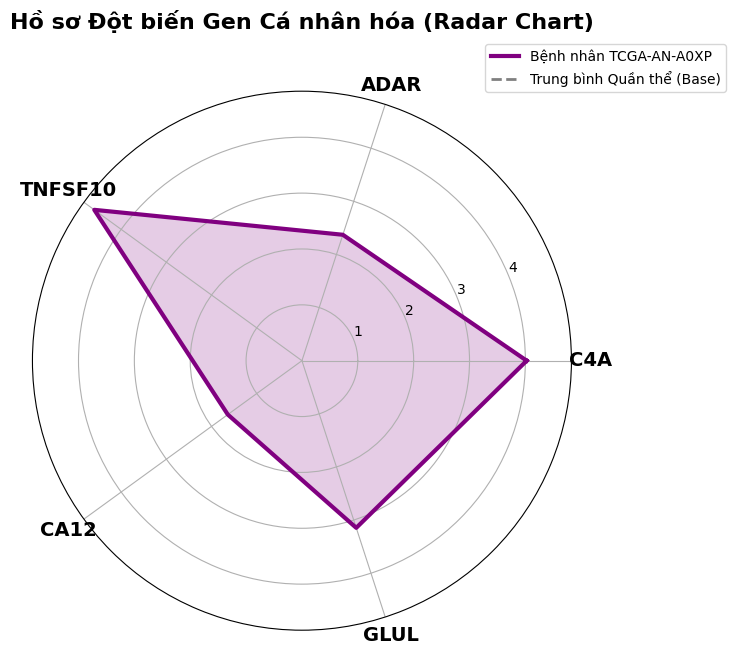

In [120]:
import math
import matplotlib.pyplot as plt

# Lấy 5 Gen mạnh nhất (Ở cuối mảng top_genes vì đã được sắp xếp tăng dần theo độ quan trọng)
categories = top_genes[-5:].tolist()
N = len(categories)

# MẸO FIX LỖI: Tìm vị trí (chỉ số cột) của 5 gen này trong từ điển top_500_genes ban đầu
gene_indices = [list(top_500_genes).index(g) for g in categories]

# Lấy dữ liệu biểu hiện gen (Đã chuẩn hóa) thông qua chỉ số cột
patient_expr = rna_500_scaled.loc[demo_pid, gene_indices].values.flatten().tolist()
pop_expr = rna_500_scaled.iloc[:, gene_indices].mean().values.flatten().tolist()

# Nối điểm cuối với điểm đầu để khép kín hình mạng nhện
patient_expr += patient_expr[:1]
pop_expr += pop_expr[:1]
angles = [n / float(N) * 2 * math.pi for n in range(N)]
angles += angles[:1]

plt.figure(figsize=(7,7))
ax = plt.subplot(111, polar=True)
plt.xticks(angles[:-1], categories, color='black', size=14, fontweight='bold')
ax.plot(angles, patient_expr, linewidth=3, linestyle='solid', color='purple', label=f'Bệnh nhân {demo_pid}')
ax.fill(angles, patient_expr, 'purple', alpha=0.2)
ax.plot(angles, pop_expr, linewidth=2, linestyle='dashed', color='grey', label='Trung bình Quần thể (Base)')
ax.fill(angles, pop_expr, 'grey', alpha=0.1)
plt.title('Hồ sơ Đột biến Gen Cá nhân hóa (Radar Chart)', size=16, fontweight='bold', y=1.1)
plt.legend(loc='upper right', bbox_to_anchor=(1.3, 1.1))
plt.show()

## 5. Tọa Độ Bệnh Nhân (Patient t-SNE Manifold)
<div class="alert alert-info">
Dữ liệu của 882 bệnh nhân tạo thành một Vũ trụ Y tế (Medical Manifold) siêu phức tạp. Thuật toán t-SNE nén không gian 1024 chiều xuống còn 2 chiều. Ngôi sao <strong>ĐỎ KHỔNG LỒ</strong> chính là bệnh nhân của chúng ta. Bác sĩ sẽ biết ca bệnh này có phải là "Ca điển hình" (Nằm ở tâm cụm) hay là "Ca hiếm" (Nằm ở vùng biên giới).
</div>

Đang định vị bệnh nhân trên Radar Không gian t-SNE...


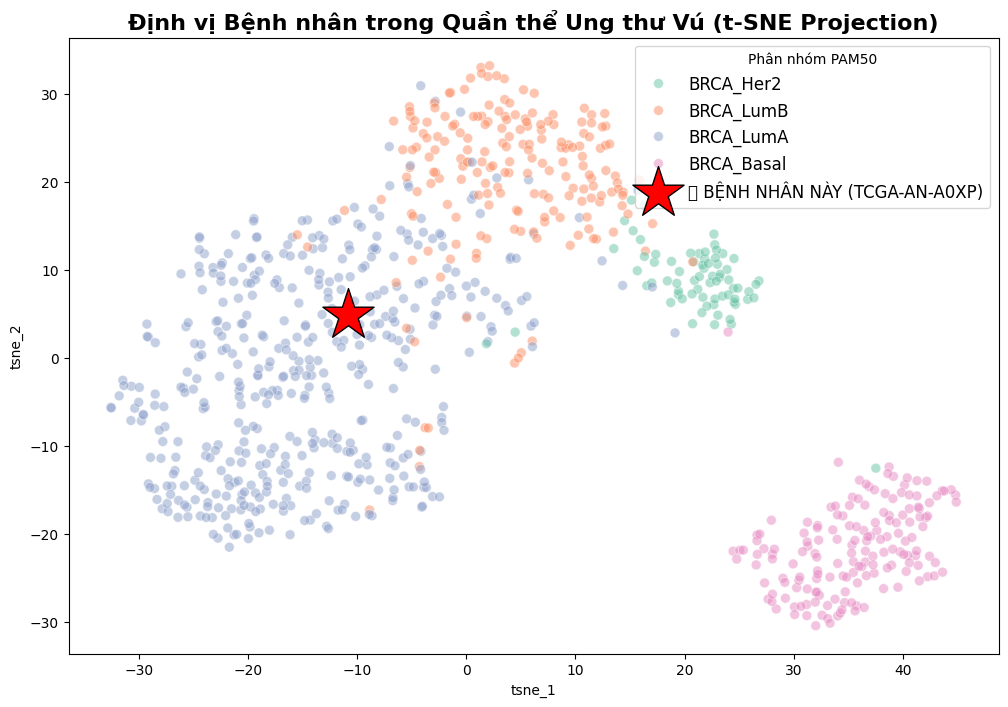

In [121]:
from sklearn.manifold import TSNE

print("Đang định vị bệnh nhân trên Radar Không gian t-SNE...")
# Dùng fusion_pca (16D) đã tính ở Cell Tiên lượng Sinh tồn để t-SNE chạy siêu nhanh
tsne = TSNE(n_components=2, random_state=42, perplexity=30)
fusion_tsne = tsne.fit_transform(fusion_pca) 

tsne_df = pd.DataFrame(fusion_tsne, columns=['tsne_1', 'tsne_2'], index=valid_pids)
tsne_df['label'] = df_clin['pam50_subtype'].values

plt.figure(figsize=(12, 8))
sns.scatterplot(x='tsne_1', y='tsne_2', hue='label', data=tsne_df, palette='Set2', s=50, alpha=0.5)
patient_coords = tsne_df.loc[demo_pid]

# Đóng dấu Bệnh nhân hiện tại bằng Ngôi sao Đỏ
plt.scatter(patient_coords['tsne_1'], patient_coords['tsne_2'], color='red', marker='*', s=1500, edgecolor='black', label=f'⭐ BỆNH NHÂN NÀY ({demo_pid})', zorder=10)
plt.title('Định vị Bệnh nhân trong Quần thể Ung thư Vú (t-SNE Projection)', fontsize=16, fontweight='bold')
plt.legend(title='Phân nhóm PAM50', fontsize=12)
plt.show()

## 6. Thước Đo Rủi Ro Tử Vong (Hazard Risk Density)
<div class="alert alert-danger">
Biểu đồ cuối cùng trả lời câu hỏi sinh tử: <strong>"Bệnh nhân này nguy kịch cỡ nào?"</strong>.<br>
Đỉnh núi màu đỏ thể hiện phân bố Điểm Rủi Ro (Hazard Score) của toàn bệnh viện. Vạch kẻ đứt màu đen chính là "Bản án" dành cho bệnh nhân này.
</div>

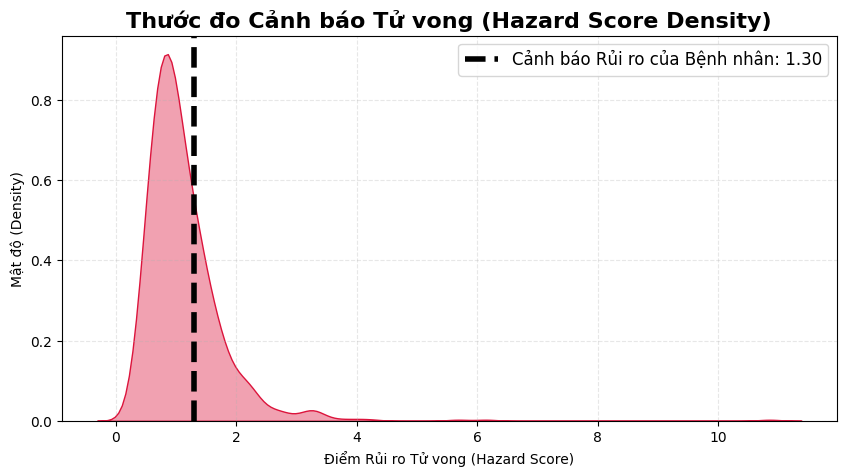

In [122]:
# Khai thác mô hình CoxPH (cph) đã huấn luyện ngầm ở phần Sinh Tồn
all_risks = cph.predict_partial_hazard(surv_df)
patient_risk = all_risks.loc[demo_pid]

plt.figure(figsize=(10, 5))
sns.kdeplot(all_risks.values, fill=True, color='crimson', alpha=0.4)
plt.axvline(x=patient_risk, color='black', linestyle='--', linewidth=4, label=f'Cảnh báo Rủi ro của Bệnh nhân: {patient_risk:.2f}')

plt.title('Thước đo Cảnh báo Tử vong (Hazard Score Density)', fontsize=16, fontweight='bold')
plt.xlabel('Điểm Rủi ro Tử vong (Hazard Score)')
plt.ylabel('Mật độ (Density)')
plt.legend(fontsize=12)
plt.grid(True, linestyle='--', alpha=0.3)
plt.show()